# Experiment 3: Data Visualization using Matplotlib and Seaborn

**Course:** Data Analysis and Visualization (DAV) Lab

## Aim
To visualise data using histograms, box plots, scatter plots, pair plots and correlation heatmaps.

## Dataset
`student_performance.csv`

## Tools Used
Python 3, Pandas, NumPy, Matplotlib, Seaborn

## 1. Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("student_performance.csv")
# Remove duplicates and incomplete rows so that plots are not affected
# (proper treatment of missing values is done in a later experiment)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print("Records used for plotting:", df.shape[0])
df.head()

Records used for plotting: 173


,Student_ID,Gender,Department,Study_Hours,Attendance_Percent,Previous_GPA,Internal_Marks,Final_Marks
0,S190,Female,CSE,2.9,82.2,6.98,29.4,42.0
1,S184,Male,CSE,4.3,80.7,6.19,16.6,44.4
2,S161,Female,CSE,7.0,79.6,6.49,23.0,47.3
3,S071,Female,CSE,3.4,65.6,7.84,16.8,16.6
4,S174,Male,CE,3.5,77.8,5.76,24.7,30.3


## 2. Histograms
A histogram shows the distribution of a single numerical variable.

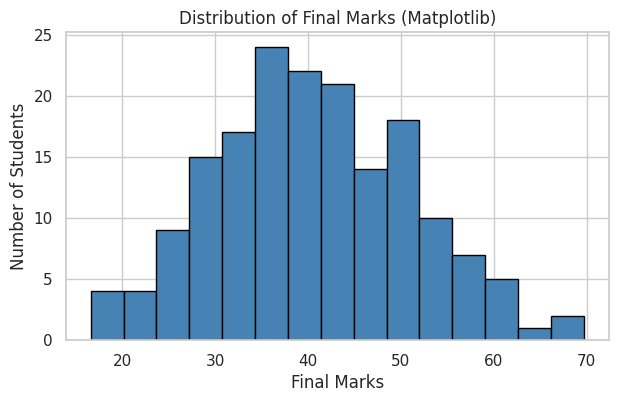

In [2]:
plt.figure(figsize=(7, 4))
plt.hist(df["Final_Marks"], bins=15, color="steelblue", edgecolor="black")
plt.title("Distribution of Final Marks (Matplotlib)")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.show()

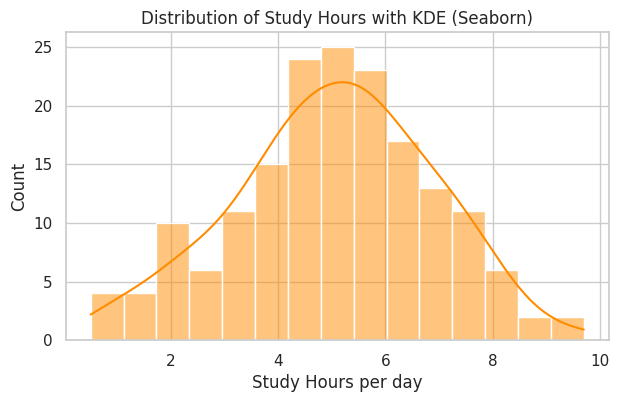

In [3]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Study_Hours"], bins=15, kde=True, color="darkorange")
plt.title("Distribution of Study Hours with KDE (Seaborn)")
plt.xlabel("Study Hours per day")
plt.show()

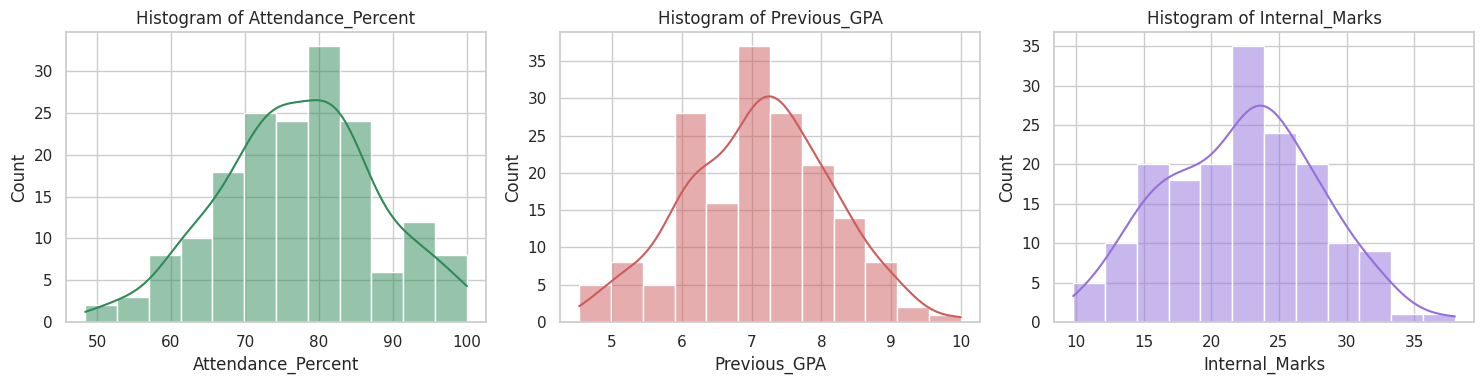

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, c in zip(axes, ["Attendance_Percent", "Previous_GPA", "Internal_Marks"],
                      ["seagreen", "indianred", "mediumpurple"]):
    sns.histplot(df[col], bins=12, kde=True, color=c, ax=ax)
    ax.set_title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

## 3. Box Plots
A box plot shows the median, quartiles and possible outliers.

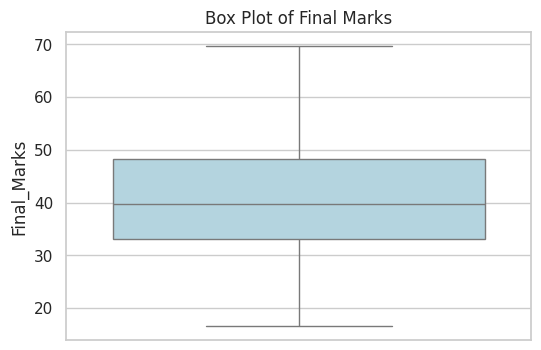

In [5]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Final_Marks"], color="lightblue")
plt.title("Box Plot of Final Marks")
plt.show()

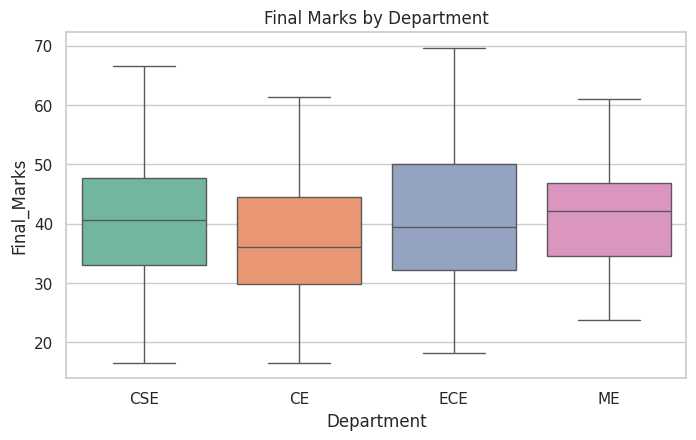

In [6]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(x="Department", y="Final_Marks", data=df, palette="Set2")
plt.title("Final Marks by Department")
plt.show()

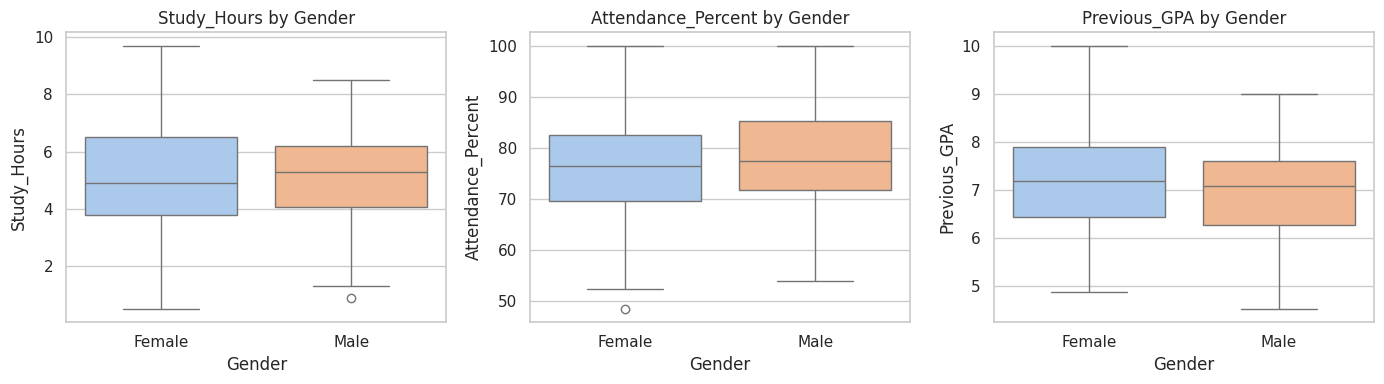

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Study_Hours", "Attendance_Percent", "Previous_GPA"]):
    sns.boxplot(x="Gender", y=col, data=df, palette="pastel", ax=ax)
    ax.set_title(f"{col} by Gender")
plt.tight_layout()
plt.show()

## 4. Scatter Plots
A scatter plot shows the relationship between two numerical variables.

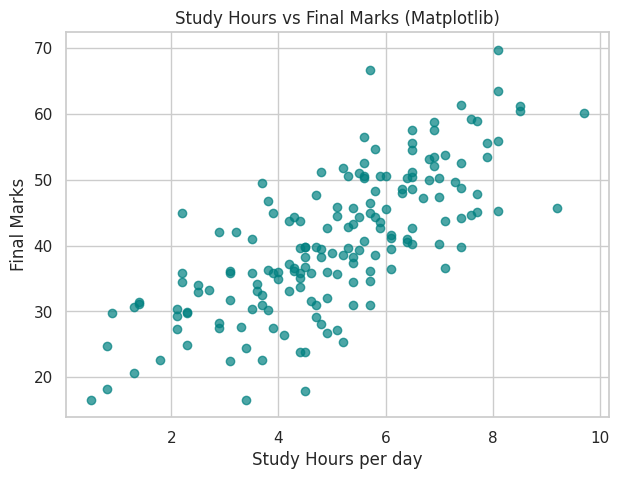

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Study_Hours"], df["Final_Marks"], color="teal", alpha=0.7)
plt.title("Study Hours vs Final Marks (Matplotlib)")
plt.xlabel("Study Hours per day")
plt.ylabel("Final Marks")
plt.show()

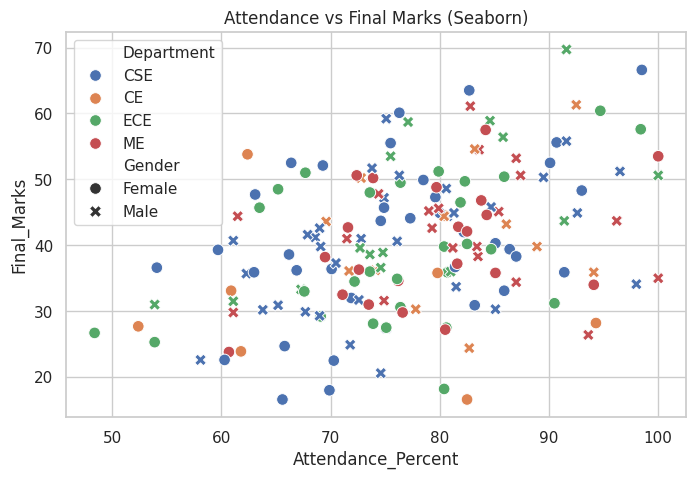

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Attendance_Percent", y="Final_Marks", hue="Department", style="Gender", data=df, s=70)
plt.title("Attendance vs Final Marks (Seaborn)")
plt.show()

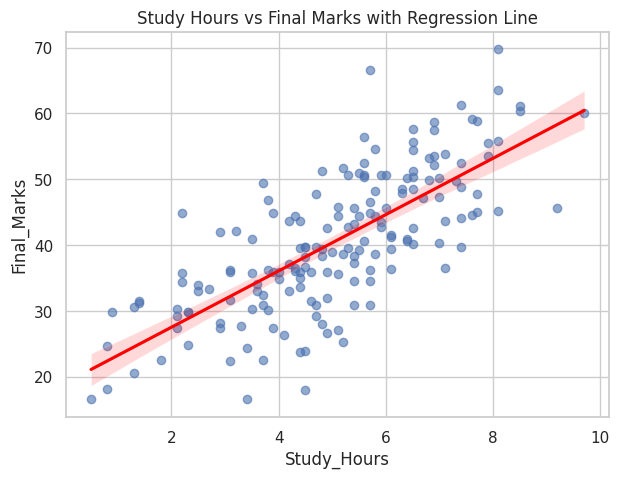

In [10]:
plt.figure(figsize=(7, 5))
sns.regplot(x="Study_Hours", y="Final_Marks", data=df, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Study Hours vs Final Marks with Regression Line")
plt.show()

## 5. Pair Plot
A pair plot draws scatter plots for every pair of numerical variables and histograms along the diagonal.

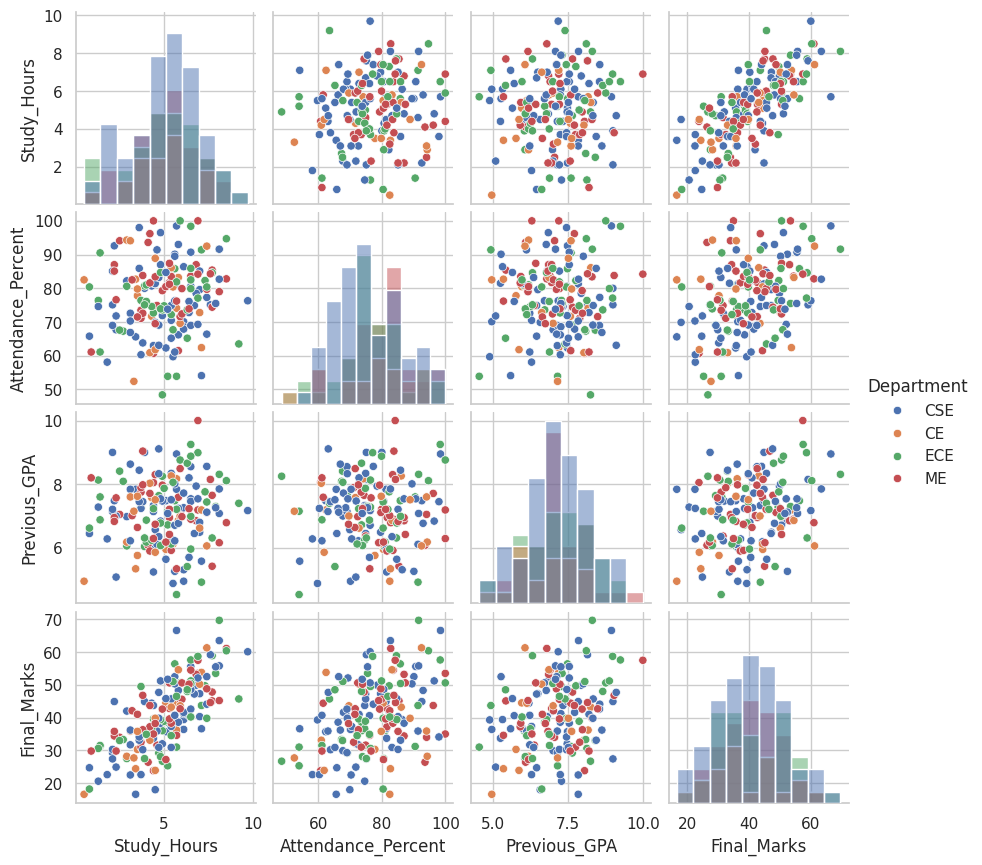

In [11]:
cols = ["Study_Hours", "Attendance_Percent", "Previous_GPA", "Final_Marks"]
sns.pairplot(df[cols + ["Department"]], hue="Department", diag_kind="hist", height=2.2)
plt.show()

## 6. Correlation Heatmap
A heatmap of the correlation matrix shows how strongly numerical variables are related (+1 strong positive, -1 strong negative, 0 none).

In [12]:
corr = df.select_dtypes(include="number").corr()
corr.round(2)

,Study_Hours,Attendance_Percent,Previous_GPA,Internal_Marks,Final_Marks
Study_Hours,1.00,0.11,0.04,0.66,0.74
Attendance_Percent,0.11,1.00,0.01,0.37,0.38
Previous_GPA,0.04,0.01,1.00,0.02,0.26
Internal_Marks,0.66,0.37,0.02,1.00,0.59
Final_Marks,0.74,0.38,0.26,0.59,1.00


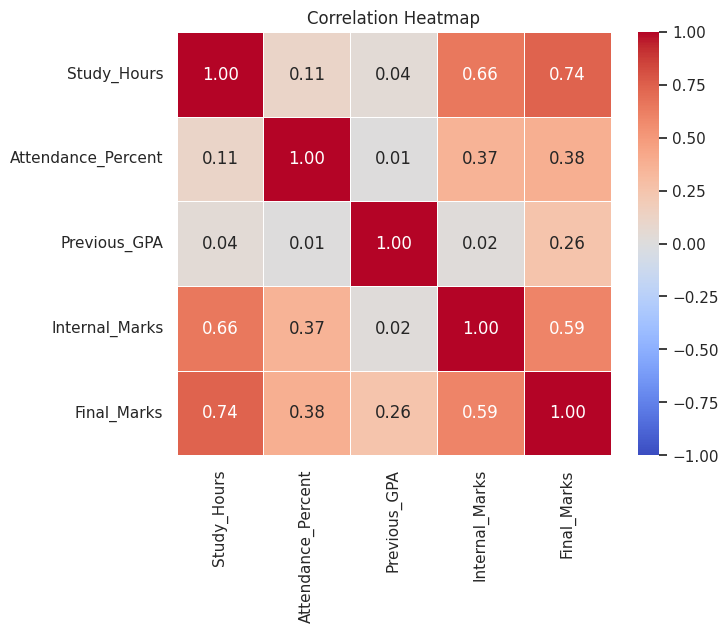

In [13]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Strongest correlations with Final_Marks
corr["Final_Marks"].drop("Final_Marks").sort_values(ascending=False).round(2)

Study_Hours           0.74
Internal_Marks        0.59
Attendance_Percent    0.38
Previous_GPA          0.26
Name: Final_Marks, dtype: float64

## Result
Histograms, box plots, scatter plots, a pair plot and a correlation heatmap were created using Matplotlib and Seaborn.

## Observations
- Final marks are roughly bell-shaped with most students in the middle range.
- Study hours and attendance have a clear positive relationship with final marks.
- Internal marks are also positively correlated with final marks.
- Box plots show similar spread of marks across departments.

## Conclusion
Visualisation makes patterns, distributions and relationships in data easy to see and guides the choice of preprocessing and models in later experiments.